In [1]:
import numpy as np
import pandas as pd
from collections import OrderedDict
from scipy.stats import ks_2samp
from scipy.stats import anderson_ksamp
from scipy.stats import multivariate_normal

from clone_competition_simulation.parameters import Parameters, TimeParameters, PopulationParameters, LabelParameters, FitnessParameters

In [2]:
# Silence the progress bar — must use the module reference directly
import clone_competition_simulation.simulation_algorithms.simulation_loop as sl
from rich.console import Console
sl.console = Console(quiet=True)

#and in joblib
def _silence_progress():
    import clone_competition_simulation.simulation_algorithms.simulation_loop as sl
    from rich.console import Console
    from loguru import logger
    
    sl.console = Console(quiet=True)
    logger.disable("clone_competition_simulation")

In [ ]:
# Loading data for all 6 timepoints

DATA_FILE = "data/41467_2022_33945_MOESM5_ESM.xlsx"  # Changed data file to reach to TP53 mouse data
def load_data_tp53(data_file):
    df = pd.read_excel(data_file, sheet_name="Supplementary Data 5", skiprows=5, skipfooter=1,
                           usecols="A,E", header=None, engine='openpyxl') 
    df.columns = ['week', 'percent_gfp']
    result = OrderedDict()
    for week in sorted(df['week'].unique()):      # unique removes duplicate values
        vals = df[df['week']==week]['percent_gfp'].values   # values returns data inside the dataframe without columns, headers or row indices
        result[int(week*7)] = vals           
    return result                    # Hands back a dictionary with days passed as keys and a list of the takeover for each mouse in the sample as values.

def mean_data_tp53(data_file):
    data = load_data_tp53(data_file)
    return OrderedDict([(t, np.mean(v)) for t, v in data.items()])

TP53_DATA = load_data_tp53(DATA_FILE)    # Returns the dictionary defined in the function above (load_data_tp53)
TP53_MEAN = mean_data_tp53(DATA_FILE)    # Returns the same dictionary but for the values it has a single mean of the gfp% instead of a list
print(TP53_MEAN)


# Functions and fixed parameters for simulations
GRID_SHAPE = (500, 500)
DIVISION_RATE = 0.27
CELLS = GRID_SHAPE[0]*GRID_SHAPE[1]

ERROR_OBJECT = {'distance': -np.inf}
NUM_CLONES = 100    

LOOP_LIMITS = 10
SIMS_PER_PARAMETER = 100
N_BOOTSTRAP = 1000

In [ ]:
def get_grid(fitness, induction, grid_shape, cells):
    # Make the initial grid with randomly placed induced cells
    initial_grid = np.zeros(grid_shape, dtype=int)
    total_mutants = int(induction*cells)
    mutant_locs = np.random.choice(grid_shape[0]*grid_shape[1], total_mutants, replace=False)
    mutant_locs = [(m // grid_shape[1], m % grid_shape[1]) for m in mutant_locs]  # Convert the random draws into array indices

    count = 0
    for i in range(total_mutants):
        initial_grid[mutant_locs[count]] = i + 1
        count += 1

    fitness_array = [1] + [fitness]*total_mutants
    label_array = [0] + [1]*total_mutants
    return initial_grid, fitness_array, label_array

def distance_ks(target, sim_results):
    return ks_2samp(target, sim_results).statistic
# Defining wrapper function 

In [ ]:
# get_grid(2,0.05,GRID_SHAPE,CELLS)    Commenting out for ease

(array([[    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        [    0,     0,     0, ...,     0,     0,     0],
        ...,
        [    0,     0,     0, ...,     0,     0,  1418],
        [    0,     0,     0, ..., 11764,     0,     0],
        [    0,     0,     0, ...,  3769,     0,     0]], shape=(500, 500)),
 [1,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,
  2,


In [ ]:
def _read_basal_counts(df):
    return OrderedDict([(t, _read_basal_counts_column(df[t])) for t in df.columns])


def _read_basal_counts_column(col):
    return np.array([v for v in col.values if (not np.isnan(v) and v > 0)], dtype=int)
    # TODO: change columns selected here so they pick up the right data

In [ ]:
def get_sim_mean_pl(parameters, target_data):
    fitness, induction = parameters['fitness'], parameters['induction']
    times = [t for t in target_data]
    try:
        initial_grid, fitness_array, label_array = get_grid(fitness, induction, GRID_SHAPE, CELLS)
        if len(fitness_array) == 1:  # Induction rate too low. No mutants on grid.
            return ERROR_OBJECT
    # The above function computes mean simulated takeover which gets used in the calculation of likelihood
        p = Parameters(algorithm='WF2D', 
                       population=PopulationParameters(initial_grid=initial_grid,cell_in_own_neighbourhood=True),
                       times=TimeParameters(times=times, division_rate=DIVISION_RATE), 
                       labels=LabelParameters(initial_label_array=label_array),
                       fitness=FitnessParameters(initial_fitness_array=fitness_array)
                       )
        
        # Just redefining get_mutant_takeover to use later
        def get_mutant_takeover(sim):
            mutants = sim.population_array.toarray()[1:]
            mutant_pop = mutants.sum(axis=0)
            if mutant_pop.max() == sim.total_pop:
                mutant_pop[np.argmax(mutant_pop):] = sim.total_pop
            return mutant_pop/CELLS


        sim_results = []
        for loop in range(LOOP_LIMITS):
            s = p.get_simulator()
            s.run_sim()
            takeover = get_mutant_takeover(s)
            sim_results.append(takeover)
        
        sim_array = np.array(sim_results)
        mean_vec = np.mean(sim_array, axis=0)
        cov_mat = np.cov(sim_array, rowvar=False)    # calculates the covariance matrix for the variables. rowvar=False tells you it is the columns 
                                                     # (not rows) that you want to analyse

        observations = np.array([np.mean(target_data[t]) for t in times])
        total_distance = multivariate_normal.logpdf(observations, mean=mean_vec, cov=cov_mat)  # creates the probability density function
        return {'distance': total_distance}

    except (Exception, SystemExit) as e:
        print('Error:', e)
        return ERROR_OBJECT         

In [ ]:
test_p = {'fitness':1.5,'induction':0.05}
# target_data = mean_data('hom', DATA_FILE)
get_sim_mean_pl(test_p, TP53_MEAN)

09:45:03 | DEBUG | Times rounded to match simulation steps:  Times used: [11.11111111 14.81481481 29.62962963]


Output()

{'distance': np.float64(-1595.24541822043)}

In [ ]:
from joblib import Parallel, delayed

def rangeModifier(valueRange,steps):
    low, high = valueRange
    gradient = (high-low)/steps
    intercept = low+gradient/2
    return(intercept,gradient)

def pseudoLikelihoodSweep(target_data, n=10,fitnessRange=(0,10),inductionRange=(0.005,0.105)):
    #values = [[0 for i in range(n)] for j in range(n)]
    #result = np.zeros((n,n))
    fi, fg = rangeModifier(fitnessRange,n)
    ii, ig = rangeModifier(inductionRange,n)

    # This function divides fitnessRange and inductionRange into a grid of nxn points, runs a systematic grid search, and calculates 
    # pseudo-likelihood score for each combination.

    grid = [(i, j, fg*i+fi, ig*j+ii) for i in range(n) for j in range(n)]

    def _worker(i, j, fit, ind):
        p = {'fitness': fit, 'induction': ind}
        r = get_sim_mean_pl(p, target_data)
        if r == ERROR_OBJECT:
            return i, j, np.nan
        return i, j, r['distance']  # already a log-likelihood, don't log again

    results = Parallel(n_jobs=-1, initializer=_silence_progress)(delayed(_worker)(i, j, fit, ind) for i, j, fit, ind in grid)

    result = np.zeros((n, n))
    values = [[None]*n for _ in range(n)]
    for i, j, val in results:
        result[i][j] = val
        values[i][j] = (fg*i+fi, ig*j+ii)
    
    return(result,values)

In [ ]:
params = {'fitness': 7.0, 'induction': 0.002}
result_one = get_sim_mean_pl(params, TP53_MEAN, )
print(result_one)

09:45:05 | DEBUG | Times rounded to match simulation steps:  Times used: [11.11111111 14.81481481 29.62962963]


Output()

{'distance': np.float64(-305.30842708625516)}


In [ ]:
fitnessRange = (1, 2)
inductionRange = (0.001, 0.03)
steps = 20
result, values = pseudoLikelihoodSweep(TP53_MEAN,fitnessRange=fitnessRange,inductionRange=inductionRange,n=steps)
# Now the ranges are specified for the ranges of TP53

In [ ]:
import matplotlib.pyplot as plt

def fmt(x, sf=2):
    return f"{x:.{sf}g}"

def likelihood_heatmap(data,fitnessRange,inductionRange,steps=10,expTransform=False):
    #if plotting likelihood, convert from log 
    if expTransform:
        data = np.exp(data- np.nanmax(data))
        data = np.where(np.isnan(data), 0, data)
        data /= data.sum()
    
    fig, ax = plt.subplots()
    im = ax.imshow((data), cmap='plasma')
    
    fi, fg = rangeModifier(fitnessRange,steps)
    ii, ig = rangeModifier(inductionRange,steps)
    
    #float(i)+0.5,'induction':float(1+j)/100
    ax.set_xticks(range(steps), [fmt(ig*float(i)+ii) for i in range(steps)])
    ax.set_yticks(range(steps), [fmt(fg*float(i)+fi) for i in range(steps)])

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    cbar = fig.colorbar(im, ax=ax)
    
    plt.show()

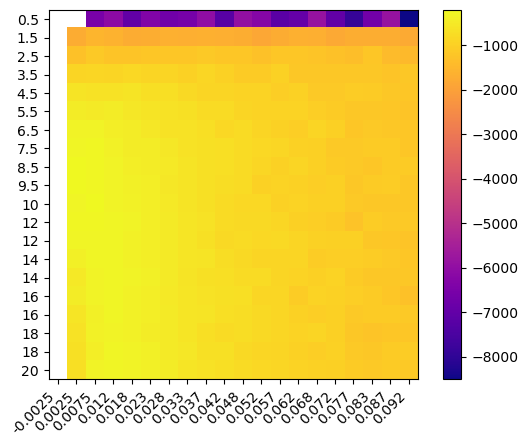

In [ ]:
likelihood_heatmap(result,fitnessRange,inductionRange,steps=steps) 
# Plots log-likelihoods

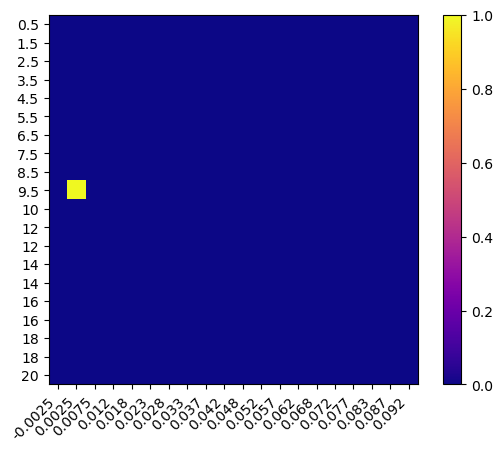

In [ ]:
likelihood_heatmap(result,fitnessRange,inductionRange,steps=steps,expTransform=True) 
# Exponentiates the log-likelihoods to give probabilities which allows us to calculate confidence intervals

In [ ]:
def getBestEdges(result,fitnessRange=(0,10),inductionRange=(0.005,0.105),n=10):
    best_x, best_y = np.unravel_index(np.argmax(result), result.shape)
    fi, fg = rangeModifier(fitnessRange,n)
    lowFit = fitnessRange[0]
    lowInd = inductionRange[0]
    ii, ig = rangeModifier(inductionRange,n)
    edgeX = (lowFit+fg*best_x, lowFit+fg*(best_x+1))
    edgeY = (lowInd+ig*best_y, lowInd+ig*(best_y+1))
    print(best_x,best_y)
    return(edgeX,edgeY)

# Finds the peak of the likelihood map (best parameter combination of fitness and induction)

In [ ]:
top_coarse_fitness, top_coarse_induction = getBestEdges(result,fitnessRange=fitnessRange, 
                                                        inductionRange=inductionRange,
                                                        n=steps)
# Changed the inputs to this function to include TP53 fitness and induction ranges

0 0


In [20]:
data = np.exp(result- np.nanmax(result))
data = np.where(np.isnan(data), 0, data)
data /= data.sum()

'''
prob_surface = np.exp(grid - np.nanmax(grid))
prob_surface = np.where(np.isnan(prob_surface), 0, prob_surface)
prob_surface /= prob_surface.sum()
'''

'\nprob_surface = np.exp(grid - np.nanmax(grid))\nprob_surface = np.where(np.isnan(prob_surface), 0, prob_surface)\nprob_surface /= prob_surface.sum()\n'

In [ ]:
def get_95ci(data,fitnessRange,inductionRange,steps,):
    def credible_interval(vals, probs, ci=0.95):
        """Central credible interval from a discrete 1D distribution."""
        cdf   = np.cumsum(probs)
        lower = vals[np.searchsorted(cdf, (1 - ci) / 2)]
        upper = vals[np.searchsorted(cdf, (1 + ci) / 2)]
        return lower, upper
    
   # Computes credible intervals by treating exponentiated likelihood as a probability distribution and integrating it
   
    data = np.exp(data- np.nanmax(data))
    data = np.where(np.isnan(data), 0, data)
    data /= data.sum()
    
    fi, fg = rangeModifier(fitnessRange,steps)
    ii, ig = rangeModifier(inductionRange,steps)
    
    x_vals = [(ig*float(i)+ii) for i in range(steps)]
    y_vals = [(fg*float(i)+fi) for i in range(steps)]
    
    marginal_x = data.sum(axis=0)   # sum over rows → distribution over x
    marginal_y = data.sum(axis=1)   # sum over cols → distribution over y
    
    x_lo, x_hi = credible_interval(x_vals, marginal_x)
    y_lo, y_hi = credible_interval(y_vals, marginal_y)
    
    print(f"x 95% CI: [{x_lo:.2f}, {x_hi:.2f}]")
    print(f"y 95% CI: [{y_lo:.2f}, {y_hi:.2f}]")

    #bounds is a dict of tuples with a new inductionRange 
    bounds = {"inductionRange":(x_lo-ig,x_hi+ig),"fitnessRange":(y_lo-fg,y_hi+fg)}
    
    return({"data":data,
            "x":{"low":x_lo,"high":x_hi},
            "y":{"low":y_lo,"high":y_hi},
            "bounds":bounds,
            "x_vals":x_vals,
            "y_vals":y_vals,
            "marginal_x":marginal_x,
            "marginal_y":marginal_y})

In [ ]:
ci_tp53 = get_95ci(result,fitnessRange,inductionRange,steps)   # changed name from ci_hom to ci_tp53

x 95% CI: [0.00, 0.00]
y 95% CI: [9.50, 9.50]


In [23]:
import matplotlib.pyplot as plt

def plot_marginals(ci_result):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    x_vals = np.array(ci_result["x_vals"])
    y_vals = np.array(ci_result["y_vals"])

    marginal_x = ci_result["marginal_x"]
    marginal_y = ci_result["marginal_y"]

    x_lo = ci_result["x"]["low"]
    x_hi = ci_result["x"]["high"]
    y_lo = ci_result["y"]["low"]
    y_hi = ci_result["y"]["high"]
    
    # heatmap
    axes[0].imshow(ci_result["data"], origin='lower', extent=[min(x_vals), max(x_vals), min(y_vals), max(y_vals)], cmap='inferno', aspect='auto')
    axes[0].axvline(x_lo, color='w', linestyle='--', label='x CI')
    axes[0].axvline(x_hi, color='w', linestyle='--')
    axes[0].axhline(y_lo, color='c', linestyle='--', label='y CI')
    axes[0].axhline(y_hi, color='c', linestyle='--')
    axes[0].set_title('Joint distribution')
    axes[0].legend(fontsize=8)
    
    # marginal x
    axes[1].plot(x_vals, marginal_x)
    axes[1].axvline(x_lo, color='r', linestyle='--', label=f'95% CI')
    axes[1].axvline(x_hi, color='r', linestyle='--')
    axes[1].set_title('Marginal x')
    axes[1].legend()
    
    # marginal y
    axes[2].plot(y_vals, marginal_y)
    axes[2].axvline(y_lo, color='r', linestyle='--', label='95% CI')
    axes[2].axvline(y_hi, color='r', linestyle='--')
    axes[2].set_title('Marginal y')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

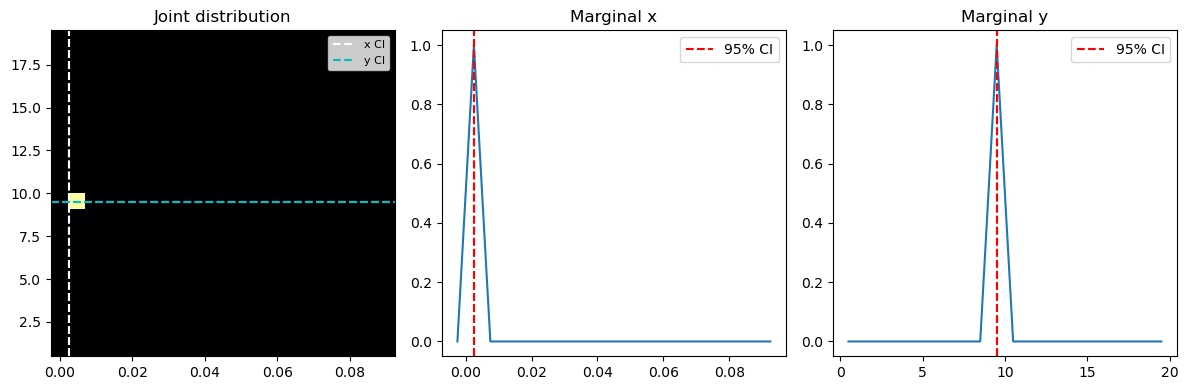

In [ ]:
plot_marginals(ci_tp53)   # also changed here from ci_hom to ci_tp53

# Look in the area of the peak specifically for a better distribution

In [ ]:
result_tp53_tight, values_tp53_tight = pseudoLikelihoodSweep(TP53_MEAN,fitnessRange=ci_tp53["bounds"]["fitnessRange"],inductionRange=ci_tp53["bounds"]["inductionRange"],n=steps)

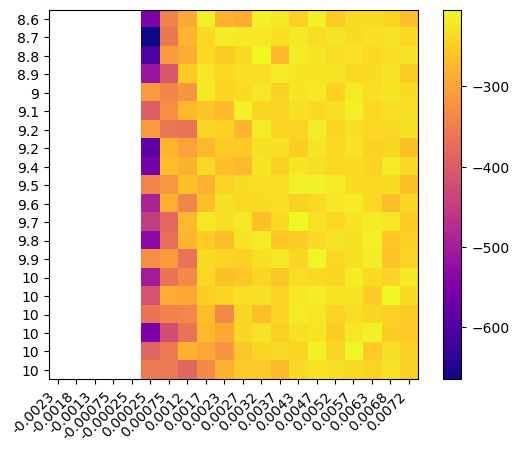

In [ ]:
likelihood_heatmap(result_tp53_tight,ci_tp53["bounds"]["fitnessRange"],ci_tp53["bounds"]["inductionRange"],steps=steps)

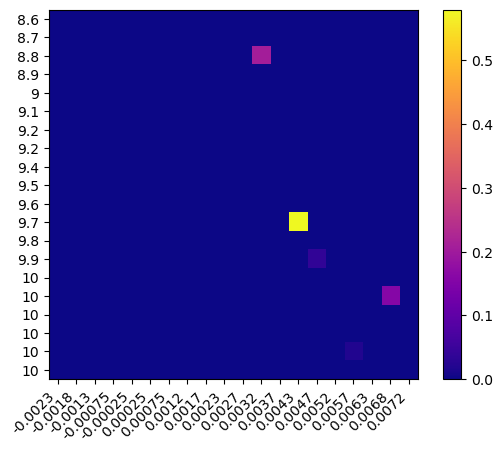

In [ ]:
likelihood_heatmap(result_tp53_tight,ci_tp53["bounds"]["fitnessRange"],ci_tp53["bounds"]["inductionRange"],steps=steps,expTransform=True)

In [ ]:
ci_tp53_tight = get_95ci(result_tp53_tight,ci_tp53["bounds"]["fitnessRange"],ci_tp53["bounds"]["inductionRange"],steps)

x 95% CI: [0.00, 0.01]
y 95% CI: [8.75, 10.05]


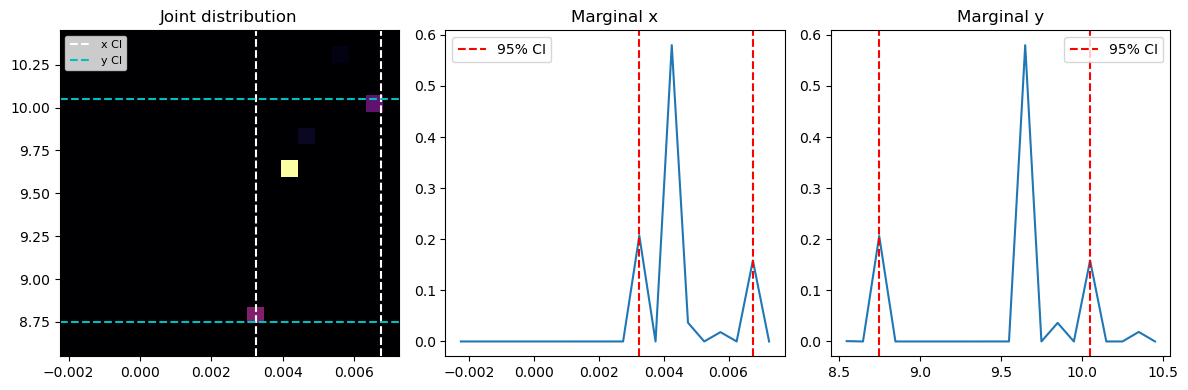

In [ ]:
plot_marginals(ci_tp53_tight)

In [30]:
np.exp(1)

np.float64(2.718281828459045)

# Make some plots (do the best fits fit?)

In [47]:
from scipy.stats import sem

def run_sim(parameters, target_data, return_clone_sizes=False):
    fitness, induction = parameters['fitness'], parameters['induction']
    times = [t for t in target_data]

    try:
        initial_grid, fitness_array, label_array = get_grid(fitness, induction, GRID_SHAPE, CELLS)
        if len(fitness_array) == 1:  # Induction rate too low. No mutants on grid.
            return ERROR_OBJECT

        p = Parameters(algorithm='WF2D', 
               population=PopulationParameters(initial_grid=initial_grid,cell_in_own_neighbourhood=True),
               times=TimeParameters(times=times, division_rate=DIVISION_RATE), 
               labels=LabelParameters(initial_label_array=label_array),
               fitness=FitnessParameters(initial_fitness_array=fitness_array)
               )
        
        clone_counts = np.zeros(len(times), dtype=int)
        sim_distributions = [[] for i in range(len(times))]
        if p:
            for loop in range(LOOP_LIMITS):
                s = p.get_simulator()
                s.run_sim()
                for i, t in enumerate(times):
                    clone_sizes = s.get_clone_sizes_array_for_non_mutation(t=t, index_given=False, exclude_zeros=True,
                                                                       label=1)
                    clone_counts[i] += len(clone_sizes)
                    sim_distributions[i].extend(clone_sizes)

                if np.all(clone_counts >= NUM_CLONES):
                    # Have got enough clones
                    break

            if not np.all(clone_counts >= NUM_CLONES):
                # Reached loop limit before getting required number of clones.
                return ERROR_OBJECT

            res = OrderedDict([
                (t, np.random.choice(sim_distributions[i], size=NUM_CLONES, replace=False)) for i, t in enumerate(times)
            ])
            if return_clone_sizes:
                return res

            total_distance = sum([distance_ks(target_data[t], res[t]) for t in target_data])
            return {'distance': total_distance}
        else:
            return ERROR_OBJECT
    except (Exception, SystemExit) as e:
        print('Error')
        print(e)
        return ERROR_OBJECT
        
'''
def get_sim_means(parameters, num, data):
    # Take many samples of N clones. 
    # Get mean clone size in each simulation.
    # Get mean of the means and the 95% interval. 
    
    res = [[] for t in data]
    for i in range(num):
        print(i, end=' ')
        np.random.seed(i)
        clone_sizes = run_sim(parameters=parameters, target_data=data, return_clone_sizes=True)
        for j, (t, clones) in enumerate(clone_sizes.items()):
            res[j].append(clones.mean())
        
    
    # Start with single cell clones at time zero
    intervals_high = [1]
    intervals_low = [1]
    means = [1]
    for r in res:
        intervals_high.append(np.quantile(r, 0.975))
        intervals_low.append(np.quantile(r, 0.025))
        means.append(np.mean(r))
    
    return means, intervals_high, intervals_low
'''

def get_sim_means(parameters, num, data, max_attempts_per_sample=10):
    res = [[] for t in data]
    
    i = 0
    attempts = 0
    successes = 0
    while successes < num:
        print(successes, end=' ')
        np.random.seed(i)
        clone_sizes = run_sim(parameters=parameters, target_data=data, return_clone_sizes=True)
        i += 1
        attempts += 1

        # Detect failure: ERROR_OBJECT won't have one entry per timepoint in `data`
        if clone_sizes is ERROR_OBJECT or set(clone_sizes.keys()) != set(data.keys()):
            if attempts - successes > max_attempts_per_sample * num:
                raise RuntimeError("Too many failed simulations — check parameters.")
            continue

        for j, (t, clones) in enumerate(clone_sizes.items()):
            res[j].append(clones.mean())
        successes += 1

    intervals_high = [1]
    intervals_low = [1]
    means = [1]
    for r in res:
        intervals_high.append(np.quantile(r, 0.975))
        intervals_low.append(np.quantile(r, 0.025))
        means.append(np.mean(r))
    
    return means, intervals_high, intervals_low

def plot_data(results, colour=None, label=None, err_stat=sem, elinewidth=2, capsize=4, markersize=3):
    x = results.keys()
    y = [results[k].mean() for k in results]
    yerr = [err_stat(results[k]) for k in results]
    plt.errorbar(x, y, yerr=yerr, label=label, c=colour, 
                 elinewidth=elinewidth, 
                 capsize=capsize, capthick=elinewidth,
                 markersize=markersize,
                 fmt='o')

def ci_to_params(ci_result):
    #returns the value half way between CIs

    #use bounds as names are unambigous
    bounds = ci_result['bounds']
    
    fit = np.mean(bounds["fitnessRange"])
    ind = np.mean(bounds["inductionRange"])
    return {'fitness': fit, 'induction': ind}

In [ ]:
# Load the data
TP53 = load_data_tp53(DATA_FILE)

In [ ]:
TP53_PARAMS = ci_to_params(ci_tp53_tight)

In [ ]:
tp53_means, tp53_interval_high, tp53_interval_low = get_sim_means(TP53_PARAMS, 100, TP53)

10:03:47 | DEBUG | Times rounded to match simulation steps:  Times used: [11.11111111 29.62962963 62.96296296 92.59259259]


0 

Output()

10:03:48 | DEBUG | Times rounded to match simulation steps:  Times used: [11.11111111 29.62962963 62.96296296 92.59259259]


1 

...

60 

Output()

61 

Output()

62 

In [ ]:
plt.figure(figsize=(6.5, 5))

'''
data = HET
colour_sim = 'm'
colour_data = 'm'
times = [0] + [t for t in data]
plt.plot(times, het_means, label='+/- fit', c=colour_sim)
plt.fill_between(times, het_interval_high, het_interval_low, alpha=0.3, color=colour_sim)
plot_data(data, label='+/- data', colour=colour_data, markersize=3)


data = HOM
colour_sim = 'r'
colour_data = 'r'
times = [0] + [t for t in data]
plt.plot(times, hom_means, label='-/- fit', c=colour_sim)
plt.fill_between(times, hom_interval_high, hom_interval_low, alpha=0.3, color=colour_sim)
plot_data(data, label='-/- data', colour=colour_data)

data = WT
colour_sim = 'k'
colour_data = 'k'
times = [0] + [t for t in data]
plt.plot(times, wt_means, label='+/+ fit', c=colour_sim)
plt.fill_between(times, wt_interval_high, wt_interval_low, alpha=0.3, color=colour_sim)
plot_data(data, label='+/+ data', colour=colour_data)
'''

data = TP53
colour_sim = 'k'
colour_data = 'k'
times = [0] + [t for t in data]
plt.plot(times, tp53_means, label='+/+ fit', c=colour_sim)
plt.fill_between(times, tp53_interval_high, tp53_interval_low, alpha=0.3, color=colour_sim)
plot_data(data, label='+/+ data', colour=colour_data)

plt.xlim(left=0)
plt.legend(bbox_to_anchor=(1.03, 1))
plt.yscale('log')
plt.ylabel('Mean clone size')
plt.xlabel('Time (days)')
plt.ylim(bottom=1)
plt.yticks([1, 10, 100], [1, 10, 100]);
plt.tight_layout()